In [1]:
# import os
# os.chdir("../..")

from occultence import *
import occultence
occultence.version()

'0.5.5'

(0.99, 1.015)

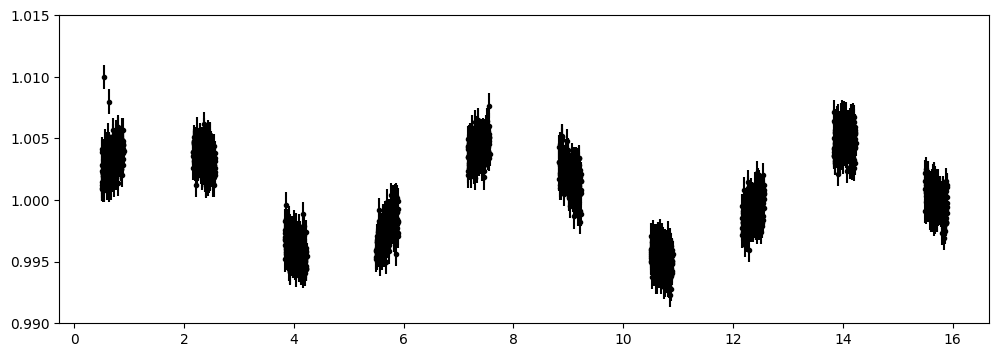

In [52]:
t = list(np.linspace(0.5,0.9,200))
daylength = len(t)
ndays = 10
gap = 16/24.
A = 0.005

for d in range(1,ndays):
    t.extend(np.array(t[:daylength]) + d * (1 + gap))

t = np.array(t)
ferr = 1e-3 * np.ones(len(t))
sinusoid_trend = A * np.sin(t)
f = 1 + sinusoid_trend + (ferr * (np.random.randn(len(t))))
f[22] = 1.01 # add a cosmic
f[63] = 1.008 # add a cosmic
f[50] = 0.0 # add a zero flux point

# f *= np.linspace(1,1.01, len(t)) # add a linear trend for the GP to remove
plt.figure(figsize=(12,4))
plt.errorbar(t,f,ferr,fmt='k.')
plt.ylim(0.99,1.015)

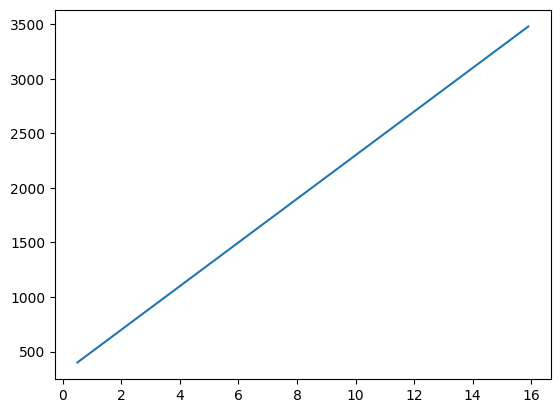

In [61]:
bkg = np.ones(len(t)) * 300
bkg = bkg + (200*t)
plt.plot(t, bkg)

In [62]:
targ = LightCurve(name = "test",
                  time = t,
                  flux = f,
                  timelike = {'bkg':bkg},
                  uncertainty = np.abs(ferr),
                  telescope = "None",
                  filter="None",
                  metadata={'R_star':0.1*u.R_sun, 'M_star':0.1*u.M_sun})

In [75]:
# targ.plot(quantity="bkg", ylims=[0,5000])
targ.mask_timelike_threshold(timelike_key = 'bkg', threshold = 2000, op=">", verbose=True)


            50.00% of data is flagged as > the threshold for bkg of 2000.
            


In [82]:
targ.get_clean_mask()
# self.get_clean_timelike()
targ.masks

{'bkg': array([0., 0., 0., ..., 1., 1., 1.]),
 'total': array([0, 0, 0, ..., 1, 1, 1])}

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


array([<Axes: ylabel='flux'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: xlabel='Time [d]'>],
      dtype=object)

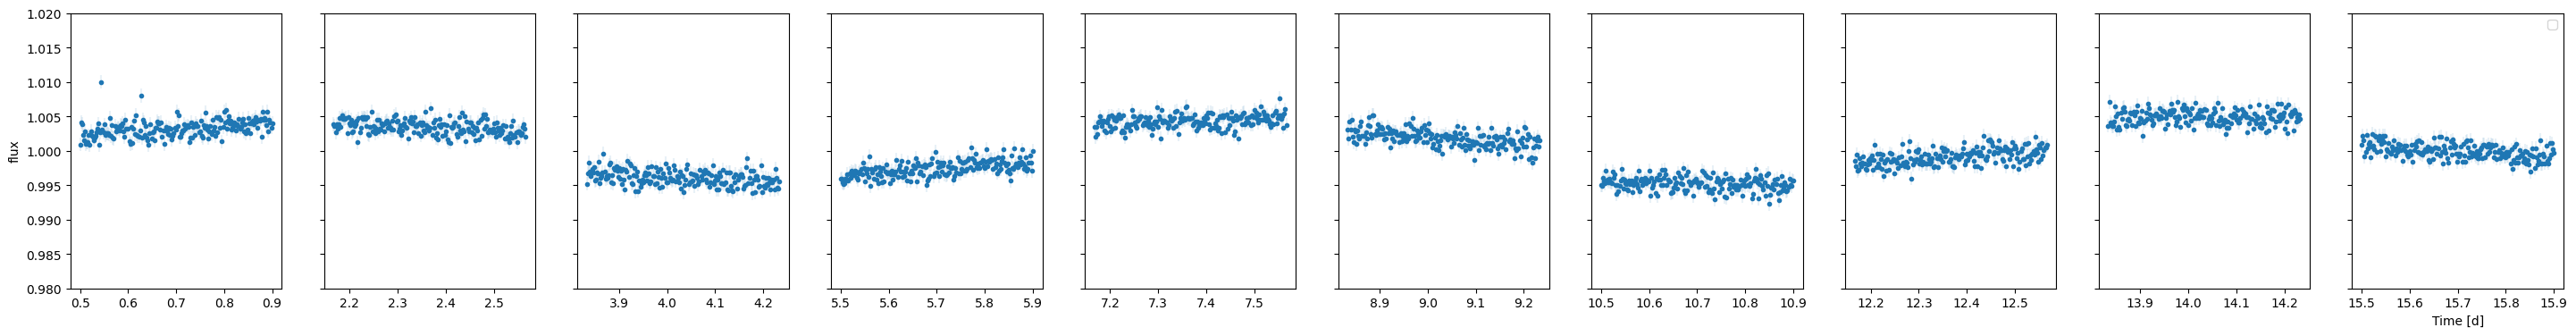

In [66]:
targ.plot()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


(0.0, 1.1)

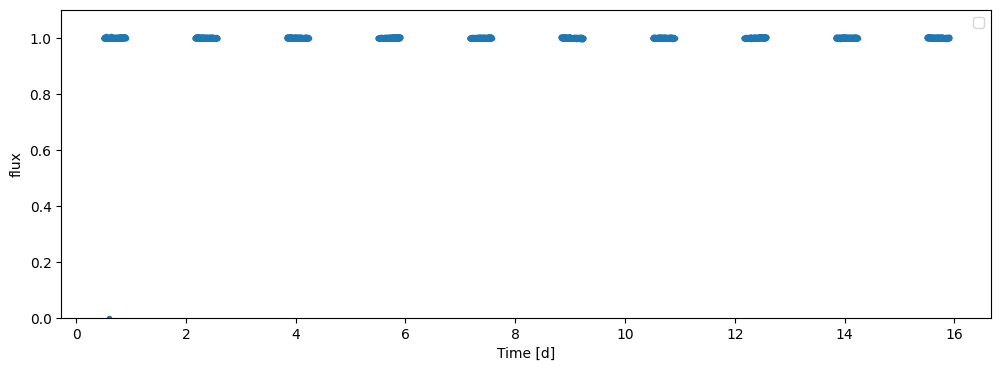

In [58]:
targ_norm = targ.normalize_each_night()
ax = targ_norm.plot_all()
ax.set_ylim(0, 1.1)

/Users/catrionamurray/anaconda3/envs/occultence/lib/python3.9/site-packages/occultence/flare_finding/flare_model.py:207: RuntimeWarning: overflow encountered in exp
  * np.exp(
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


array([<Axes: ylabel='flux'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: xlabel='Time [d]'>],
      dtype=object)

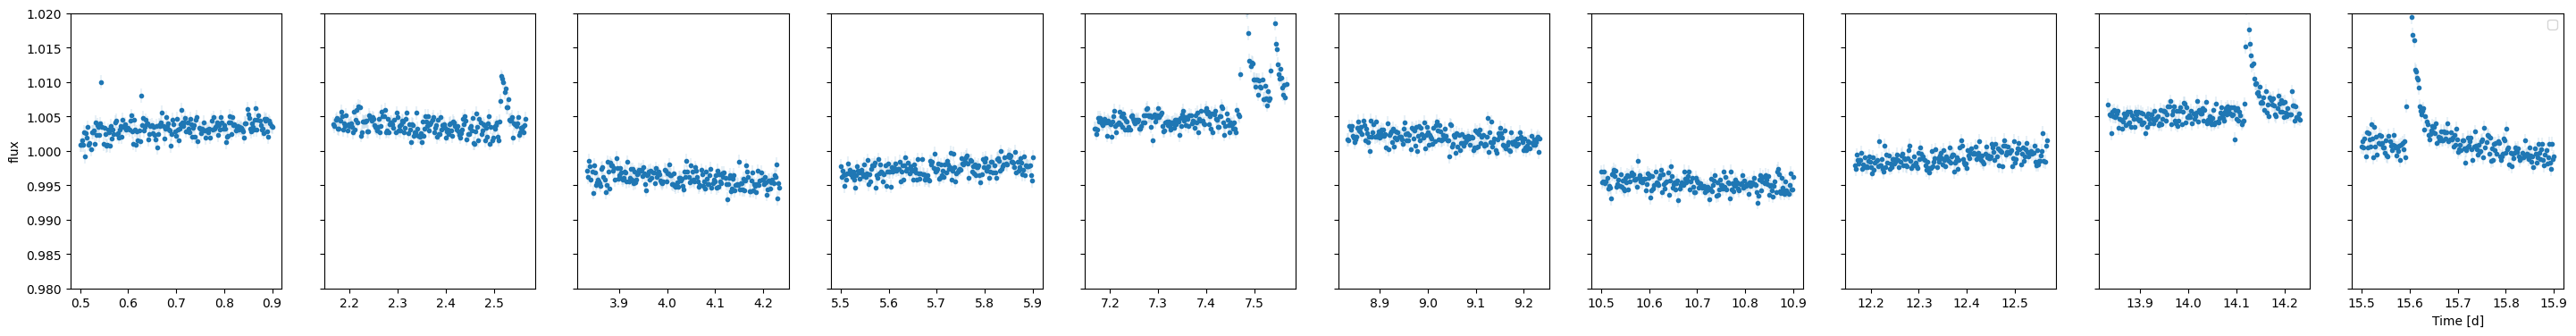

In [42]:
flare_lc = targ_norm.inject_flares(nfake=5, amp_range=[1e-3, 0.05], model="mendoza2022")
flare_lc.plot()

In [43]:
flare_lc.metadata

{'name': 'test_injectedflares',
 'target': 'test',
 'R_star': <Quantity 0.1 solRad>,
 'M_star': <Quantity 0.1 solMass>,
 'flares_injected': {'nflares_injected': 5,
  'flare_params': {'t0': [15.597289211700776,
    2.5174811610723005,
    7.474928407375342,
    7.537488364304498,
    14.121635946485585],
   'fwhm': [0.010987305386904095,
    0.010171022347906006,
    0.011212962706768586,
    0.006870956010594974,
    0.01054069119856822],
   'amp': [0.035327679282004296,
    0.008065687558585955,
    0.03608581707065882,
    0.02249122499434735,
    0.019304807785746145]}}}

In [45]:
# flare_lc.split_by

In [44]:
# i_split, _ = flare_lc.split_time(split=flare_lc.split_by)
# i_split

In [46]:
clip_lc = flare_lc.global_and_local_sigma_clip(global_sc_kw={'nsigma_upper':5, 
                                                             'nsigma_lower':5},
                                               local_sc_kw={'nsigma_upper':3, 
                                                            'nsigma_lower':np.inf, 
                                                            'running_mean_boxsize':0.4}
                                              )

/Users/catrionamurray/anaconda3/envs/occultence/lib/python3.9/site-packages/numpy/core/fromnumeric.py:784: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


array([<Axes: ylabel='flux'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: xlabel='Time [d]'>],
      dtype=object)

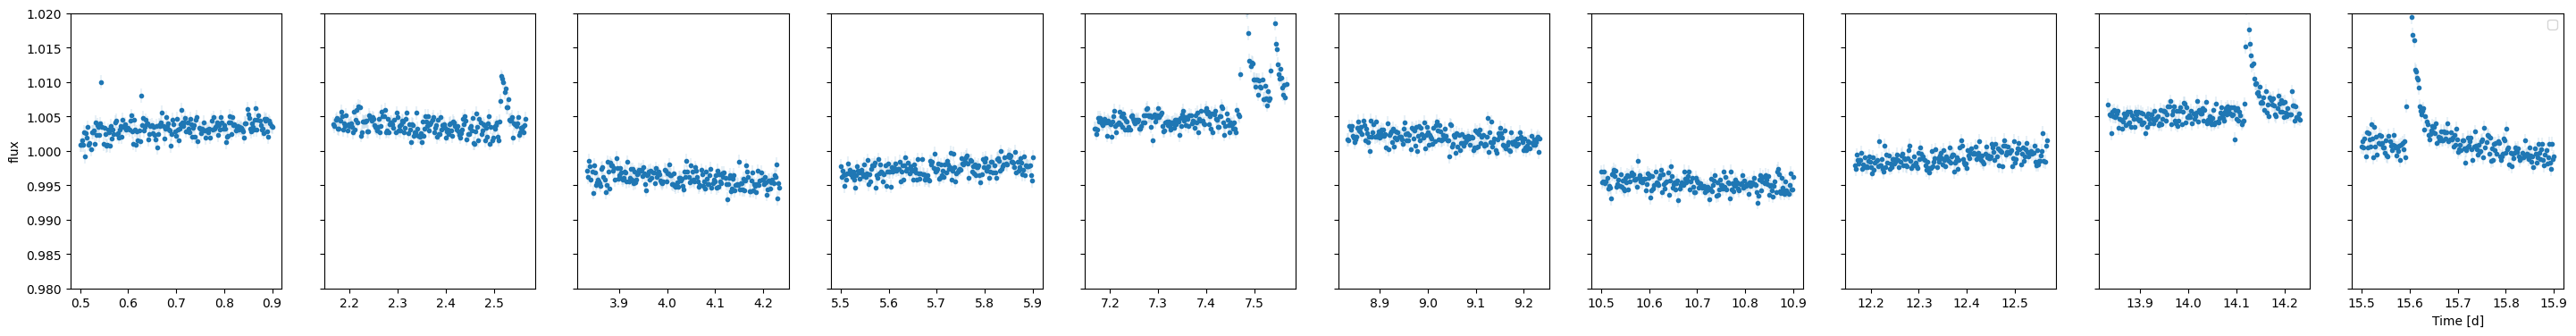

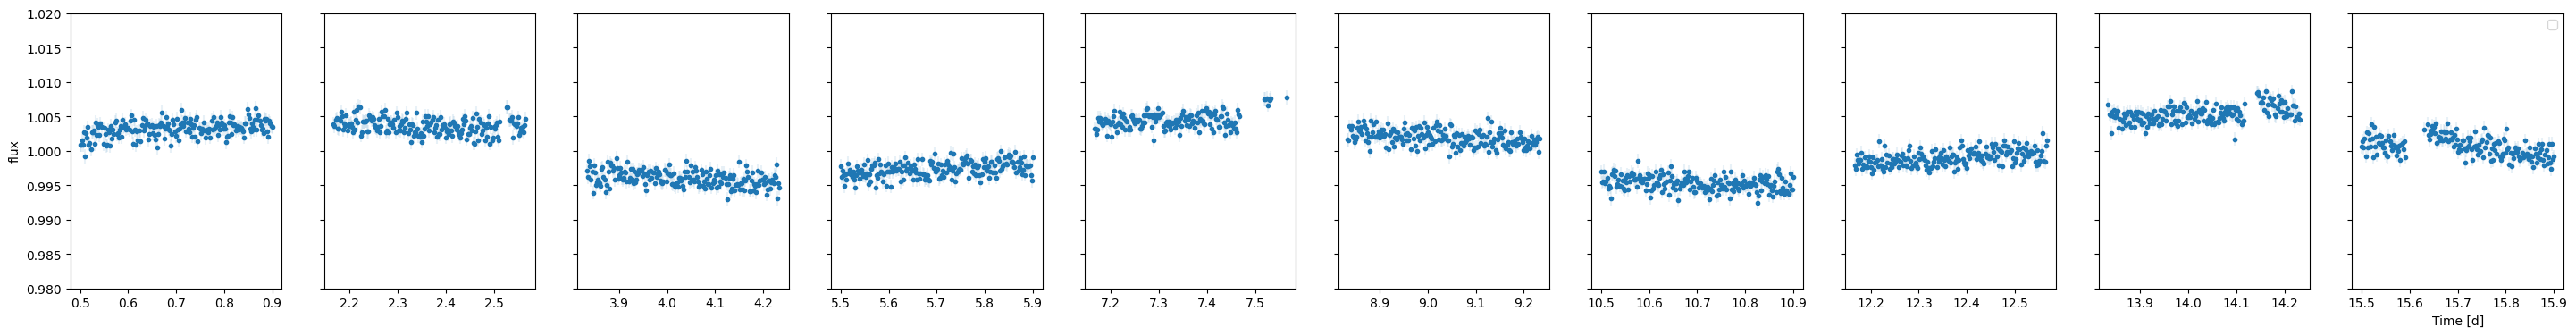

In [47]:
flare_lc.plot()
clip_lc.plot()

/Users/catrionamurray/anaconda3/envs/occultence/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a, func=_nanmedian, keepdims=keepdims,


The best recovered period=6.379856115107913 d


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


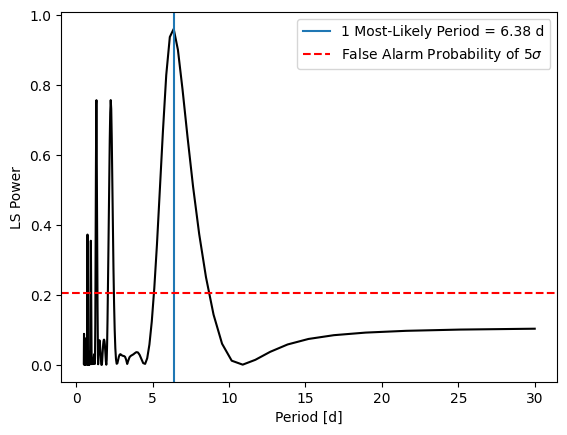

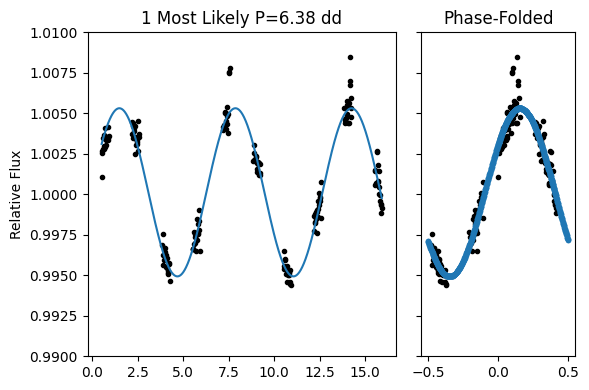

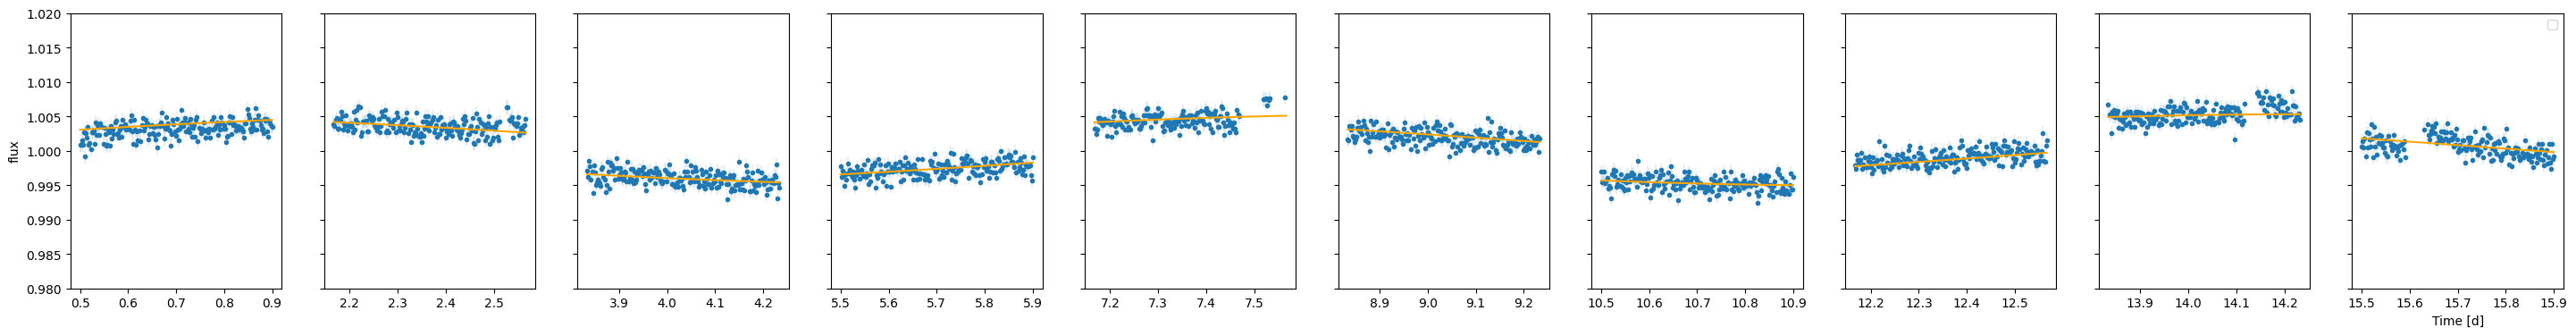

In [48]:
detrended_targ = clip_lc.lombscargle_detrend(plot=True, ls_binning=30*u.minute,
                                  minimum_frequency=1/(30*u.d),
                                  maximum_frequency=1/(0.5*u.d),
                                  samples_per_peak=10,
                                  npeaks=1,
                                  nsigma=5)

In [49]:
detrended_targ.metadata

{'name': 'test_injectedflares_sigmaclipped_lsdetrend',
 'target': 'test',
 'R_star': <Quantity 0.1 solRad>,
 'M_star': <Quantity 0.1 solMass>,
 'flares_injected': {'nflares_injected': 5,
  'flare_params': {'t0': [15.597289211700776,
    2.5174811610723005,
    7.474928407375342,
    7.537488364304498,
    14.121635946485585],
   'fwhm': [0.010987305386904095,
    0.010171022347906006,
    0.011212962706768586,
    0.006870956010594974,
    0.01054069119856822],
   'amp': [0.035327679282004296,
    0.008065687558585955,
    0.03608581707065882,
    0.02249122499434735,
    0.019304807785746145]}},
 'ls_period': <Quantity 6.37985612 d>,
 'ls_power': <Quantity 0.96068237>,
 'ls': <astropy.timeseries.periodograms.lombscargle.core.LombScargle at 0x2ac006fd0>,
 'fap': array(0.20524118),
 'recovered_period': True}

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


array([<Axes: ylabel='flux'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: xlabel='Time [d]'>],
      dtype=object)

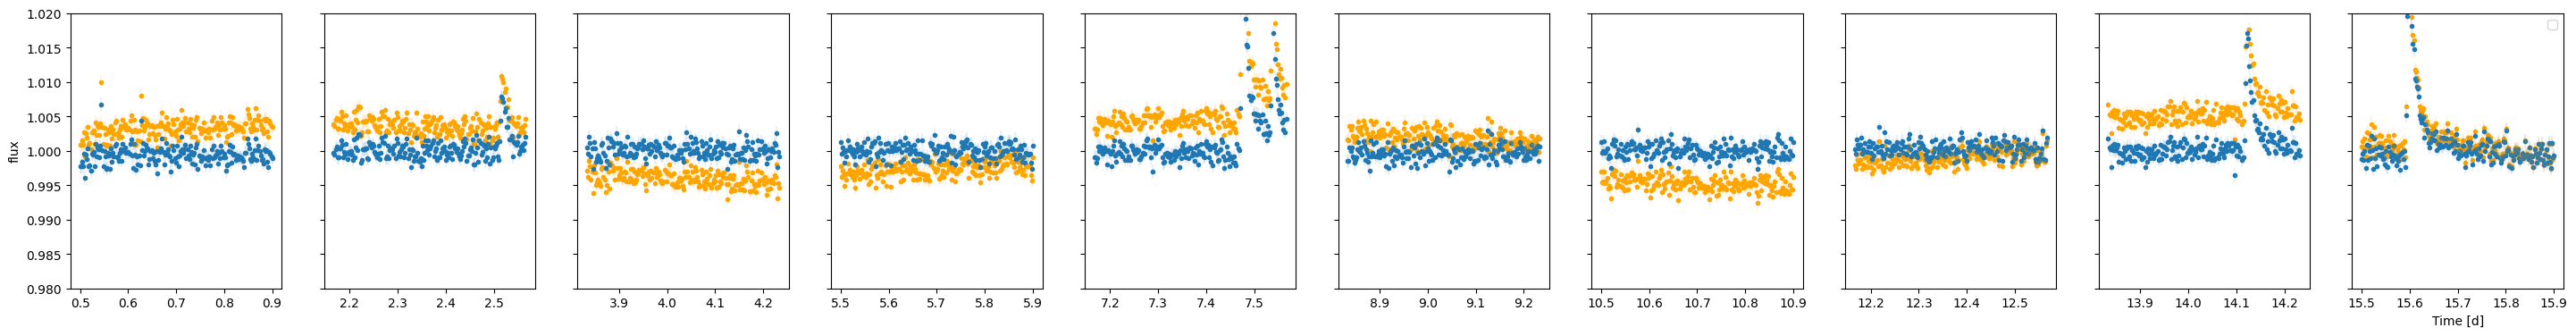

In [50]:
flare_lc_detrended = flare_lc._create_copy()
flare_lc_detrended.timelike['flux'] = flare_lc_detrended.timelike['flux']/detrended_targ.timelike['ls_model']

ax = flare_lc.plot(color='orange')
flare_lc_detrended.plot(ax=ax)

/Users/catrionamurray/anaconda3/envs/occultence/lib/python3.9/site-packages/numpy/core/fromnumeric.py:784: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



            There are 4 flare candidates with >5.0 min over 3$\sigma$
            


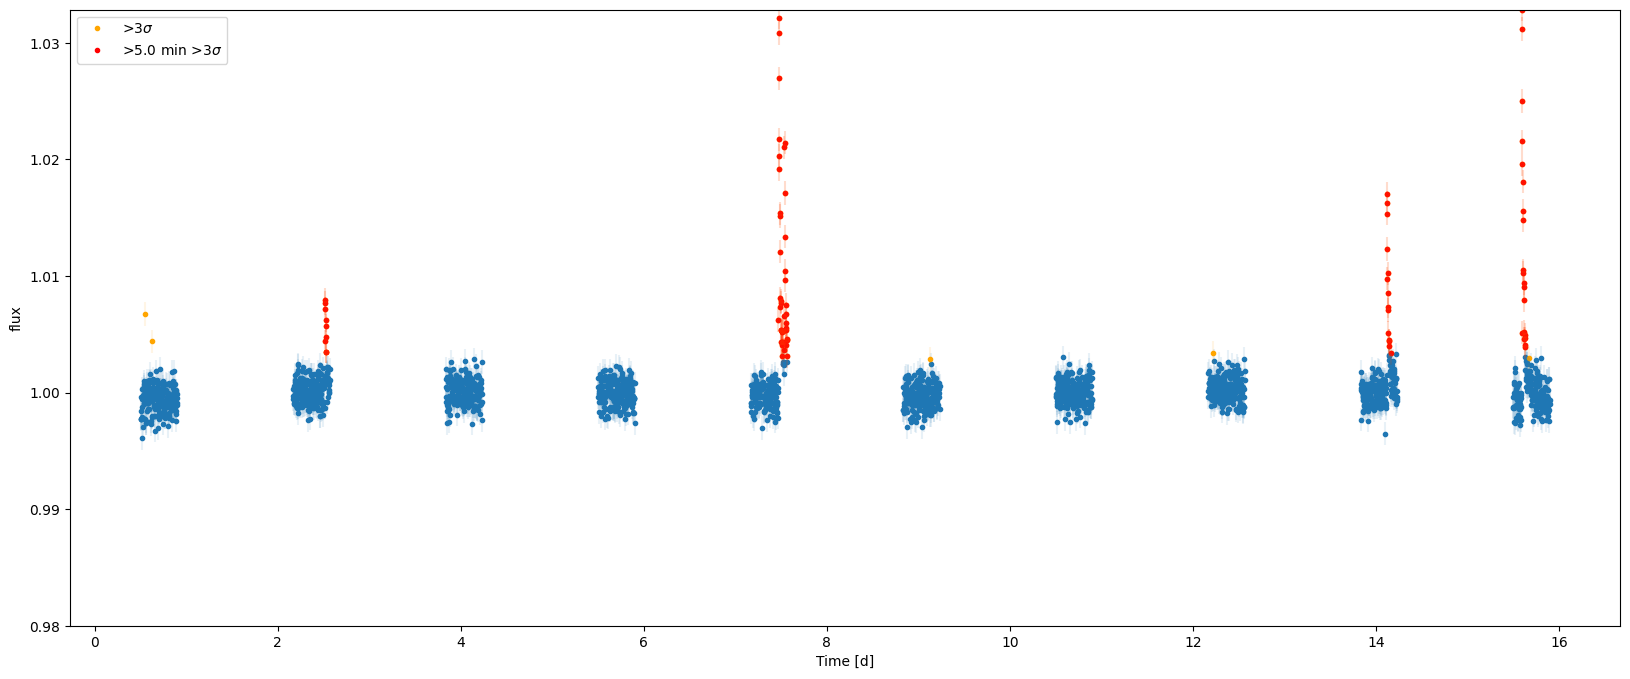

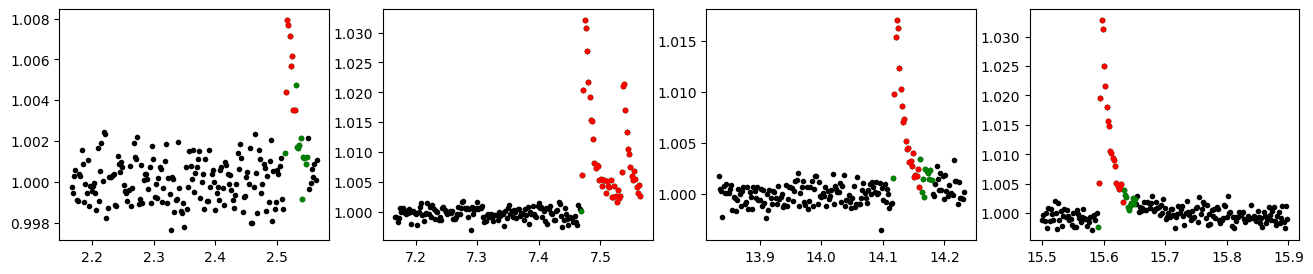

In [51]:
flares_masked = flare_lc_detrended.detect_flares_sclip(plot=True, 
                                                       min_flare_separation=60*u.minute,
                                                      tbuffer_after=30*u.min)

In [16]:
flares_masked.metadata

{'name': 'test_injectedflares_sigmaclipped_flaresremoved',
 'target': 'test',
 'R_star': <Quantity 0.1 solRad>,
 'M_star': <Quantity 0.1 solMass>,
 'flares_injected': {'nflares_injected': 5,
  'flare_params': {'t0': [12.418000824435966,
    9.030430889103524,
    2.4156294682161157,
    2.218422221851363,
    2.3499802971934676],
   'fwhm': [0.007691364453566664,
    0.007900927800909084,
    0.0057513972911019265,
    0.007592667387506537,
    0.007373460551913284],
   'amp': [0.011298058398368348,
    0.020712921467307594,
    0.043971963690704954,
    0.02265759046810687,
    0.01740881118894179]}},
 'flares_detected': {'nflares': 5,
  'thresholds': {'duration': <Quantity 5. min>,
   'sigma': 3,
   'separation': <Quantity 60. min>},
  'flare_regions': [[224, 244],
   [289, 307],
   [322, 355],
   [1096, 1132],
   [1523, 1553]],
  'flare_frequency': <Quantity 1.38888889 1 / d>,
  'global_sc_kw': {'nsigma_upper': 5, 'nsigma_lower': 5},
  'local_sc_kw': {'nsigma_upper': 3,
   'nsigma_l

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


array([<Axes: ylabel='flux'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: xlabel='Time [d]'>],
      dtype=object)

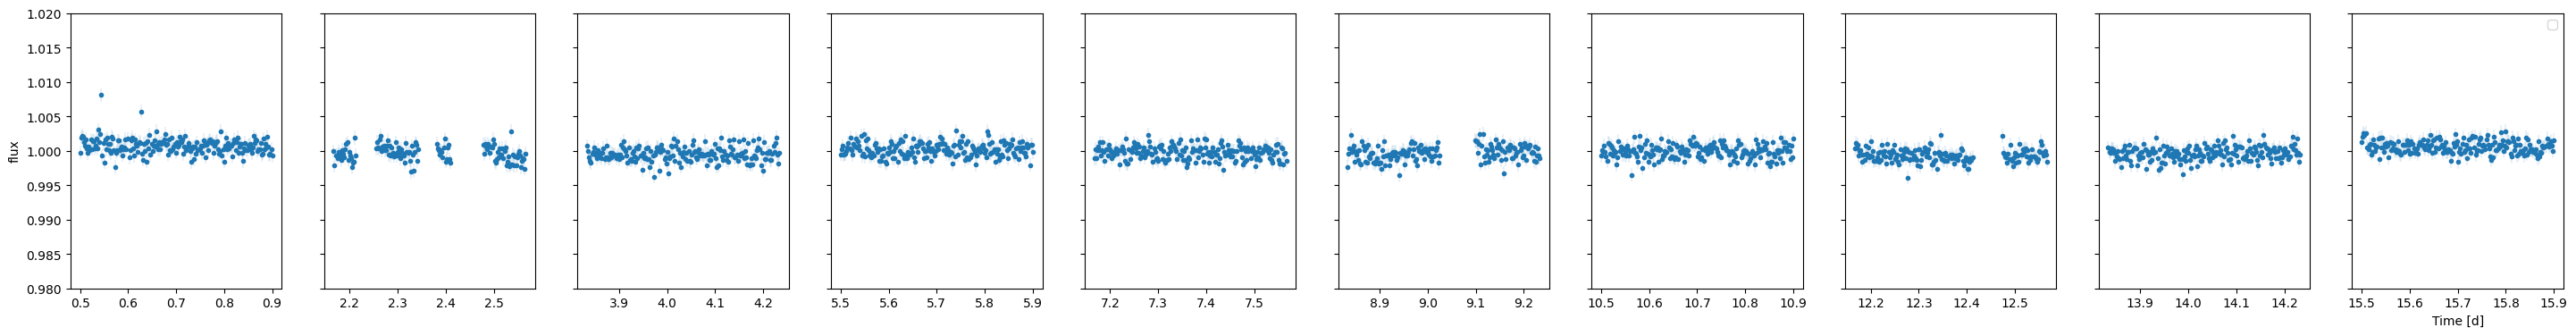

In [17]:
flares_masked.plot()

In [42]:
# flares_to_model = flares_masked.metadata['flares_detected']['flare_regions']
# flares_modeled = flares_masked.model_each_flare([1,1,1,1,1], 
#                                flare_lc_detrended.time.value, 
#                                flare_lc_detrended.flux, 
#                                flare_lc_detrended.uncertainty, 
#                                n_before=3, 
#                                n_after=5, 
#                                method="mendoza2022",
#                                tgap=(1 * u.hour).to_value('d'), 
#                                plot=True)

# flares_modeled.metadata

In [56]:
flares_masked

<🌟 Lightcurve test_injectedflares_sigmaclipped_flaresremoved (2000t) 🌟>

In [59]:
flares_masked.split_day(6)

<🌟 Lightcurve test_injectedflares_sigmaclipped_flaresremoved (200t) 🌟>

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (2,) + inhomogeneous part.